# E-Commerce Customer Behavior & Sales Analysis

## Data Preparation

Таблиці, які будуть використовуватись в данному дослідженні, були створені з основного датасета за допомогою SQL-запитів у BigQuery. Усі SQL-запити збережені у файлі **SQL_Queries.md**

**Таблиця v_cleaned:**

Рівень агрегації: 1 рядок - 1 замовлення.

Призначення: транзакційна таблиця для аналізу продажів та поведінки клієнтів.

- **Order_ID** - унікальний ідентифікатор замовлення, що забезпечує унікальність кожного запису на рівні транзакції.

- **Customer_ID** - унікальний ідентифікатор клієнта, який дозволяє агрегувати транзакції до рівня клієнта (RFM, churn, LTV).

- **Date** - дата здійснення замовлення.

- **Age** - вік клієнта на момент покупки.

- **Gender** - стать клієнта, використовується для аналізу поведінки та revenue за гендерними сегментами.

- **City** - місто клієнта.

- **Product_Category** - категорія товару.

- **Unit_Price** - ціна одиниці товару.

- **Quantity** - кількість одиниць товару в замовленні, допомогая оцінити обсяги продажу та поведінки покупців.

- **Discount_Amount** - сума знижки, застосована до замовлення.

- **Total_Amount** - фактична сума замовлення після знижки, порахована за формулою: Unit_Price × Quantity – Discount_Amount. 

- **Payment_Method** - спосіб оплати, для аналізу платіжної поведінки клієнтів.

- **Device_Type** - тип пристрою, з якого здійснено покупку.

- **Session_Duration_Minutes** - тривалість сесії перед покупкою (у хвилинах).

- **Pages_Viewed** - кількість переглянутих сторінок перед покупкою.

- **Is_Returning_Customer** - ознака повторного клієнта (1 - returning, 0 - new), призначається для аналізу повторних покупок

- **Delivery_Time_Days** - кількість днів доставки, використовується для аналізу впливу логістики на задоволеність і churn.

- **Customer_Rating** - оцінка клієнтом покупки (1-5 зірок), використовується для аналізу задоволеності та її впливу на повторні покупки.

Додані часові колонки:

- **order_month** - місяць замовлення (назва або формат YYYY-MM), агрегації для monthly KPI.

- **order_year** - рік замовлення.

- **order_month_num** - порядковий номер місяця (1–12).



**Таблиця v_customer_churn:**

Рівень агрегації: 1 рядок - 1 клієнт.

Призначення: аналіз на рівні клієнта та підготовка даних для сегметації клієнтів, формулюванню гіпотез і побудові ML-моделей.

- **Customer_ID** - унікальний ідентифікатор клієнта, дозволяє агрегувати поведінку клієнта на рівні всієї історії покупок.

- **first_purchase** - дата першої покупки клієнта, визначає початок життєвого циклу клієнта.

- **last_purchase** - дата останньої покупки клієнта, використовується для розрахунку recency та churn.

- **frequency** - загальна кількість замовлень клієнта за весь період, показує активність клієнта.

- **monetary** - загальна сума витрат клієнта за весь період (SUM Total_Amount - це історичний LTV (Lifetime Value)).

- **lifetime_days** - кількість днів між first_purchase і last_purchase, тривалість життєвого циклу клієнта.

- **reference_date** - максимальна дата покупки в датасеті, використовується як точка відліку для розрахунку recency та churn. Так як дані історичні (2023-2024), при її розрахунку CURRENT_DATE() не використовувався.

- **recency_days** - кількість днів від останньої покупки клієнта до reference_date. Чим більше значення, тим довше клієнт не купує, тим вищий ризик churn.

- **churn** - 1 - клієнт вважається таким, що припинив активність, 0 - активний клієнт. Поріг для визначення churn - 90 днів, визначено на основі колонки **recency_days**.

## Імпорт необхідних бібліотек

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery
import plotly.express as px
import plotly.graph_objects as go


##  Імпорт таблиць створених у BigQuery


In [2]:
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = "C:\\Users\\MSI\\Downloads\\noble-resolver-488513-g4-3934cc48366d.json"

In [3]:
client = bigquery.Client()

query_orders = """
SELECT *
FROM `noble-resolver-488513-g4.dataset.v_cleaned`
"""

query_customers = """
SELECT *
FROM `noble-resolver-488513-g4.dataset.v_customer_churn`
"""

df_orders = client.query(query_orders).to_dataframe()
df_customers = client.query(query_customers).to_dataframe()


## Дослідницький аналіз даних (EDA) таблиці замовлень

Спочатку я досліджую **таблицю замовлень df_orders**, щоб аналізувати сезонність, категорії товарів, поведінку по device.

In [4]:
# Загальний вигляд
df_orders.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,order_month,order_year,order_month_num
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,...,Digital Wallet,Mobile,14,9,True,13,4,2023-05-01,2023,5
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,...,Credit Card,Desktop,14,8,True,6,2,2023-10-01,2023,10
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,...,Credit Card,Mobile,15,10,True,9,4,2023-12-01,2023,12
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,...,Digital Wallet,Desktop,16,13,True,4,4,2023-05-01,2023,5
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,...,Credit Card,Mobile,14,7,True,6,4,2023-06-01,2023,6


In [5]:
# Розмір таблиці замовлень
print(f"Розмір таблиці: {df_orders.shape}")
print(f"Кількість транзакцій: {df_orders.shape[0]:,}")
print(f"Кількість колонок: {df_orders.shape[1]}")

Розмір таблиці: (17049, 21)
Кількість транзакцій: 17,049
Кількість колонок: 21


In [6]:
# Загальна інформація про дані
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  dbdate 
 3   Age                       17049 non-null  Int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  Int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  Int64  
 14  Pages_

В таблиці є і числові, і категоріальні дані, пусті значення відсутні.

In [7]:
# Перевірка кількості дублікатів
print("Кількість дублікатів:", df_orders.duplicated().sum())

Кількість дублікатів: 0


In [8]:
# Описова статистика
df_orders.describe().round(2) 

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,order_year,order_month_num
count,17049.0,17049.00,17049.0,17049.00,17049.00,17049.0,17049.0,17049.0,17049.0,17049.0,17049.0
mean,34.95,447.90,3.01,69.79,1277.44,14.54,9.0,6.5,3.9,2023.19,5.69
std,11.05,722.32,1.42,240.70,2358.44,2.93,2.26,3.49,1.13,0.39,3.62
min,18.0,5.05,1.0,0.00,6.21,4.0,1.0,1.0,1.0,2023.0,1.0
25%,26.0,73.26,2.0,0.00,172.97,13.0,7.0,4.0,3.0,2023.0,2.0
50%,35.0,174.68,3.0,0.00,455.85,15.0,9.0,6.0,4.0,2023.0,5.0
75%,42.0,494.57,4.0,32.71,1267.75,17.0,11.0,8.0,5.0,2023.0,9.0
max,75.0,7900.01,5.0,6538.29,37852.05,26.0,18.0,25.0,5.0,2024.0,12.0


**Висновки:**

**1. Портрет клієнта та замовлення:**

 - Вік: середній вік покупця - 35 років (від 18 до 75). Основна частина - це люди від 26 до 42 років, платоспроможна аудиторія.

 - Середнє значення колонки Total_Amount або середній чек (AOV) складає 1 277.44, проте його медіана - 455.85 значно нижча за середнє значення. Це вказує на наявність дорогих клієнтів, які сильно тягнуть середній показник вгору, бо максимальний чек - 37 852.

**2. Поведінка на сайті:**

 - Активність: у середньому користувачі проводять на сайті 14.5 хвилин та переглядають 9 сторінок.

**3. Логістика та задоволеність:**

 - Доставка: середній термін доставки - 6.5 днів. Максимум - 25 днів виглядає як аномалія або проблема, яку треба дослідити.

 - Рейтинг: клієнти задоволені сервісом - середня оцінка 3.9 з 5. Медіана в 4.0 свідчить про стабільно високу якість, але є замовлення з оцінкою 1.0, що корелюють із затримками доставки.

**4. Ціноутворення та знижки:**

- Знижки: більше 50% замовлень проходять взагалі без знижок (медіана - 0.0). Знижки застосовуються точково, але можуть сягати значних сум (max 6538).

- Кількість товарів: зазвичай купують 3 одиниці товару за раз.


Так як з описової статистики я бачу великий розрив між середнім і медіаною в Total_Amount, я хочу побудувати гістограму розподілу доходів і зобразити можливі викиди на графіку як box plot.

**Гістограма розподілу доходів Revenue**

In [ ]:
fig = px.histogram(
    df_orders,
    x="Total_Amount",
    nbins=100,
    title="Distribution of Revenue",
    marginal="box",
    template="plotly_white",
    color_discrete_sequence=['#5176A1']
)

fig.update_traces(
    marker_line_color="white", 
    marker_line_width=0.5        
)

fig.update_layout(
    xaxis_title='Revenue',
    yaxis_title='Count'
)
    
fig.show()

**Висновки:**

1. Переважна більшість замовлень (майже 12 000) зосереджена в діапазоні від 0 до 1000, це масовий ринок, який створює об'єм транзакцій.

2. Графік має сильно правоскошений розподіл і дуже довгий правий хвіст, що тягнеться до 35 000, це поодинокі, але надзвичайно дорогі замовлення. Тут працює логіка Парето: замовлення в хвості формують левову частку каси.

3. На Box Plot є величезна кількість викидів за межами вусів, це не помилки в даних, а VIP-клієнти, чи товари преміум‑категорій або великі закупівлі.

4. Розрив між середнім і медіаною: так як медіана всередині Box Plot знаходиться дуже близько до нуля, то середнє значення - 1277 є сильно завищеним через ці поодинокі великі суми.

Щоб краще зрозуміти, як ці доходи формуються у часі та які саме фактори на них впливають, далі проаналізую ключові бізнес‑метрики: динаміку доходу, категорії товарів, поведінку нових і повторних клієнтів та середню вартість замовлення за допомогою аналітичного блоку графіків.

Почну з аналізу виручки в динаміці, щоб побачити сезонність, піки та спад.

**1. Як змінювалися доходи компанії протягом місяців? Чи існують пікові періоди продажів, і з чим вони можуть бути пов’язані?**

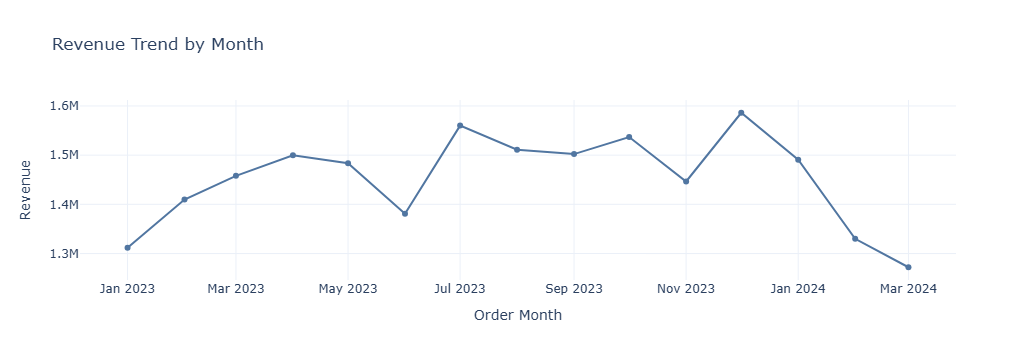

In [10]:
df_monthly = df_orders.groupby('order_month', as_index=False)['Total_Amount'].sum()

fig = px.line(
    df_monthly,
    x='order_month',
    y='Total_Amount',
    title='Revenue Trend by Month',
    markers=True,
    template='plotly_white',
    color_discrete_sequence=['#5176A1']
)

fig.update_layout(
    xaxis_title='Order Month',
    yaxis_title='Revenue'
)

fig.show()


**Висновки:**

1. Загальна тенденція поступового зростання доходу у 2023 році - від 1.31M у січні до пікового значення 1.59M у грудні.

2. Найвищий показник доходу зафіксовано у грудні 2023 року, через передноворічний святковий сезон.

3. У червні 2023 спостерігався різкий спад до 1.38M, що може бути пов'язано з початком сезону відпусток або відсутністю великих маркетингових акцій у цей період.

4. Після грудневого піку почалося стрімке падіння доходів, у березні 2024 дохід впав до найнижчої точки на графіку - 1.27M.

**Рекомендації:**
1. Дослідити причини падіння доходів на початку 2024 - чи це післясвятковий спад ринку, чи наслідок закінчення топових товарів, чи інші причини.

3. Варто також дізнатись, які саме товари приносили найбільше прибутку в пікові періоди, щоб розширити асортимент до наступних високих сезонів.

**2. Які категорії товарів формують найбільшу частку доходу?**

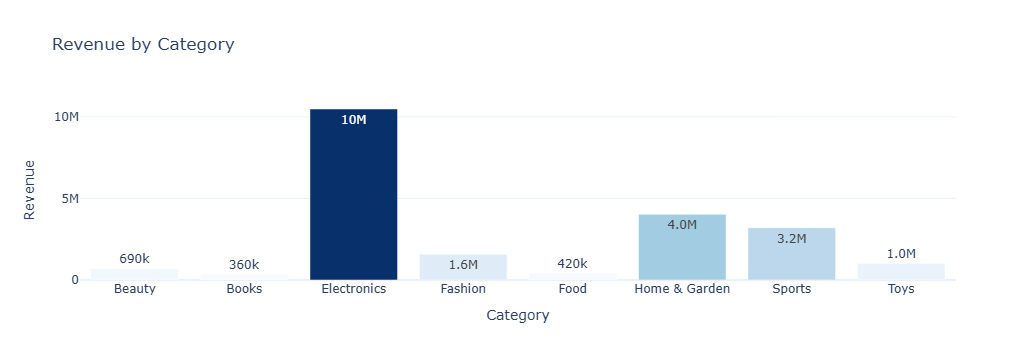

In [11]:
df_cat = df_orders.groupby('Product_Category', as_index=False)['Total_Amount'].sum()

fig = px.bar(
    df_cat,
    x='Product_Category',
    y='Total_Amount',
    color='Total_Amount',
    title='Revenue by Category',
    text_auto='.2s',
    template="plotly_white",
    color_continuous_scale='Blues'
)

fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Revenue',
    coloraxis_showscale=False
)

fig.show()


**Висновки:**

1. Категорія Electronics домінує над усіма, вона приносить 10 млн, що становить більше, ніж усі інші категорії разом узяті.

2. Категорії Books, Food та Beauty виглядають дуже слабкими на фоні інших.

**Рекомендації:**

1. Категорія Electronics - це основне джерело прибутку, тож треба налаштувати систему рекомендацій, щоб покупцям цієї категорії додатково пропонувались товари з категорії Sports або Home & Garden, де маржинальність може бути вищою.

2. Для категорії Electronics швидкість доставки є критичною. Будь-які технічні збої або проблеми з постачанням в категорії Electronics загрожують усьому прибутку компанії. Можливо, варто виділити окремі склади під лідерів продажів.

3. Зважити доцільність тримання широкого асортименту категорій Food, Books, Beauty, якщо вони приносять мінімальний дохід, але потребують витрат на логістику та зберігання. 


Також важливо оцінити структуру клієнтів:

**3. Чи бізнес більше залежить від нових покупців, чи від повторних?**

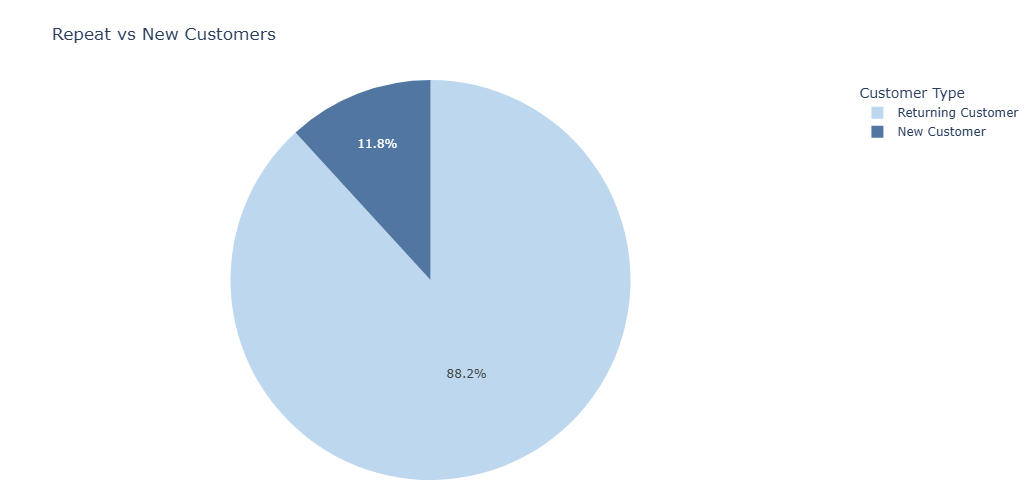

In [12]:
df_repeat = df_orders.groupby('Is_Returning_Customer', as_index=False)['Order_ID'].count()
df_repeat.rename(columns={'Order_ID': 'Orders'}, inplace=True)

df_repeat['Customer_Type'] = df_repeat['Is_Returning_Customer'].map({
    True: 'Returning Customer',
    False: 'New Customer'
})

fig = px.pie(
    df_repeat,
    names='Customer_Type',
    values='Orders',
    title='Repeat vs New Customers',
    color='Customer_Type',
    color_discrete_map={
        'Returning Customer': '#BDD7EE',
        'New Customer': '#5176A1'
    }
)

fig.update_traces(
    textposition='inside',
    textinfo='percent'
)

fig.update_layout(
    legend_title_text='Customer Type',
    legend=dict(
        itemsizing='constant',
        title_font_size=14,
        font_size=12
    ),
    height=500,
    width=1000,
    margin=dict(t=80, b=20, l=20, r=20)
)

fig.show()


**Висновки:**

1. Понад 88% усіх замовлень здійснюють постійні клієнти, це показує, що фундаментом цього бізнесу є лояльність.

2. Постійні покупці зробили понад 15 000 замовлень, тоді як нові лише близько 2 000. Це означає, що база лояльних клієнтів у 7.5 разів активніша за новачків.

3. Бізнес економічно стабільний і не залежить від постійного агресивного маркетингу для залучення трафіку, бо основна маса клієнтів повертається самостійно.

**Рекомендації:**

1. Показник 11.8% нових клієнтів може бути занизьким для активного росту бізнесу. Якщо почнеться відтік лояльних клієнтів, кількості нових може не вистачити для компенсації відтоку, тож варто подумати над стратегією залучення нових.

2. Tак як клієнти повертаються, кожен новий клієнт потенційно принесе компанії не один чек, а десятки. Це дозволить компанії витрачати більше на залучення одного нового користувача, знаючи, що він окупиться в майбутньому.

Через наявність викидів середнє значення Revenue (Total_Amount) значно перевищує її медіану. І можна подумати, що це середнє значення відірване від реальної картини і треба використовувати саме медіану. Але AOV (Average Order Value) - це важлива бізнес‑метрика, а не статистична. Тому важливо показати як значення середнього чеку змінюється протягом часу.

**4. Як змінюється середній чек (Average Order Value) по місяцях?**

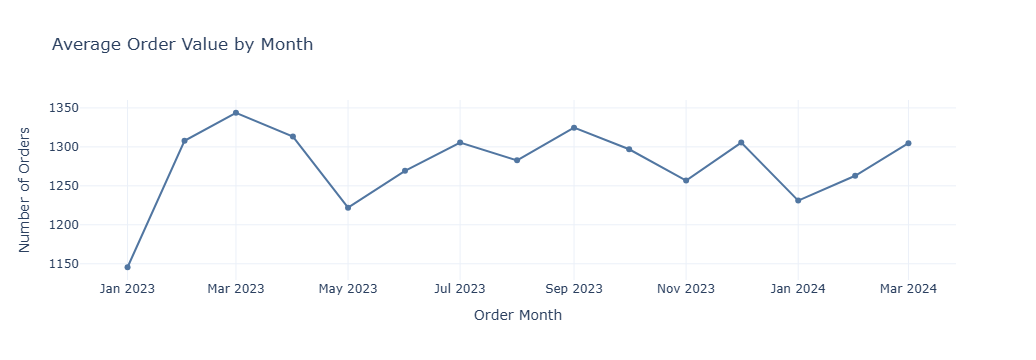

In [13]:
df_aov = df_orders.groupby('order_month', as_index=False)['Total_Amount'].mean()

fig = px.line(
    df_aov,
    x='order_month',
    y='Total_Amount',
    title='Average Order Value by Month',
    markers=True,
    template='plotly_white',
    color_discrete_sequence=['#5176A1']
)

fig.update_layout(
    xaxis_title='Order Month',
    yaxis_title='Number of Orders' 
)

fig.show()


**Висновки:**

Показник не є стабільним, є різкі коливання:

1. Рік почався з найнижчої точки у січні 2023 - 1150, після чого відбулося стрімке зростання до максимуму в березні 2023 року - понад 1340.

2. Різке падіння в травні 2023 - до 1220 може свідчити про сезонні розпродажі або зміну фокусу покупців на дешевші категорії.

3. Другий значний пік у вересні 2023 - 1325, він ймовірно пов'язаний із початком навчального року або виходом нових товарів в електроніці.

4. В грудні 2023 спостерігається зростання середнього чеку відносно листопада, яке пов'язане з передноворічним сезоном.

5. На відміну від загального доходу, який стрімко падав у березні 2024 (на графіку Revenue Trend by Month), середній чек у березні почав зростати, повернувшись до позначки 1300. Це означає, що кількість замовлень скоротилася, але ті, хто залишився, стали купувати дорожчі товари.


## Основні інсайти блоку аналізу на рівні замовлення:

**1.** Спостерігається загальна тенденція поступового зростання доходу у 2023 році, але з початку 2024 року - стрімке падіння продажів.

**2.** Найприбутковіша категорія товарів - Electronics. Категорії Books, Food та Beauty приносять найменше доходу.

**3.** Бізнес має надзвичайно лояльну клієнтську базу - 88% усіх замовлень здійснюють постійні клієнти.

**4.** Розмір середнього чеку змінюється від місяця до місяця, але не зважаючи на падіння доходу на початку 2024 року, середній чек зростав, тобто клієнти стали купувати дорожчі товари.

## Дослідницький аналіз даних (EDA) таблиці клієнтів

Щоб зрозуміти поведінку клієнтів на більш глибокому рівні, переходжу до аналізу їхньої активності, витрат та життєвого циклу. Це дозволяє побачити, які групи клієнтів приносять найбільшу цінність, хто знаходиться на межі відтоку, а хто має потенціал для зростання. Цей аналіз я продовжую дослідженням **таблиці клієнтів df_customers**, щоб робити сегментацію і розрахунок метрик на рівні клієнта.

In [14]:
# Загальний вигляд
df_customers.head(5)

,Customer_ID,first_purchase,last_purchase,frequency,monetary,lifetime_days,reference_date,recency_days,churn
0,CUST_01747,2024-03-25,2024-03-25,1,138.41,0,2024-03-25,0,0
1,CUST_01825,2024-03-25,2024-03-25,1,1085.45,0,2024-03-25,0,0
2,CUST_03938,2024-03-23,2024-03-23,1,3436.95,0,2024-03-25,2,0
3,CUST_01082,2024-03-23,2024-03-23,1,1748.14,0,2024-03-25,2,0
4,CUST_01718,2024-03-22,2024-03-22,1,75.78,0,2024-03-25,3,0


In [15]:
# Загальна інформація про дані
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     5000 non-null   object 
 1   first_purchase  5000 non-null   dbdate 
 2   last_purchase   5000 non-null   dbdate 
 3   frequency       5000 non-null   Int64  
 4   monetary        5000 non-null   float64
 5   lifetime_days   5000 non-null   Int64  
 6   reference_date  5000 non-null   dbdate 
 7   recency_days    5000 non-null   Int64  
 8   churn           5000 non-null   Int64  
dtypes: Int64(4), dbdate(3), float64(1), object(1)
memory usage: 371.2+ KB


В цій таблиці також відсутні пусті значення.

In [16]:
# Розмір таблиці клієнтів
print(f"Розмір таблиці: {df_customers.shape}")
print(f"Кількість клієнтів: {df_customers.shape[0]:,}")
print(f"Кількість колонок: {df_customers.shape[1]}")

Розмір таблиці: (5000, 9)
Кількість клієнтів: 5,000
Кількість колонок: 9


In [17]:
# Описова статистика
df_customers.describe().round(2) 

,frequency,monetary,lifetime_days,recency_days,churn
count,5000.0,5000.00,5000.0,5000.0,5000.0
mean,3.41,4355.81,195.77,124.72,0.51
std,2.18,5274.55,141.11,108.05,0.5
min,1.0,14.28,0.0,0.0,0.0
25%,2.0,889.41,51.0,38.0,0.0
50%,3.0,2493.93,209.0,93.0,1.0
75%,5.0,5796.30,319.0,184.0,1.0
max,10.0,50628.15,447.0,449.0,1.0


**Висновки:**

1. Активність та лояльність:

 - частота покупок - середній клієнт купує 3,4 рази, що є хорошим показником, але 25% бази зробили лише 2 покупки або менше

 - середній час життя клієнта в системі - 196 днів, максимальний показник сягає 447 днів, що свідчить про наявність таких клієнтів, які з сервісом понад рік.

2. Грошовий внесок monetary: середнє значення становить 4355, але медіана значно нижча - 2493, це знову підтверджує гіпотезу, що невелика група клієнтів витрачає величезні суми (максимум - 50 628), тоді як більшість приносить вдвічі менше.

3. Утримання та відтік:

 - давність замовлення recency - в середньому клієнт робив останнє замовлення 124 дні тому.

 - показник відтоку churn становить 0.51 (51%).

**Рекомендації:**

1.  Медіана recency - 93 дні та високий churn - 51% вказують на те, що клієнти роблять кілька покупок і зникають. Потрібно налаштувати Retention-маркетинг: email-розсилки або push-повідомлення для тих, хто не купував понад 60-90 днів.

2. Робота з VIP-клієнтами: так як максимальний чек більше 50 000, що у 20 разів більший за медіанний, втрата навіть одного такого клієнта відчутно вдарить по прибуткам. Для топ-сегмента (мonetary > 5796) потрібен персоналізований сервіс.


Необхідно подивитися на розподіли ключових характеристик клієнта, щоб підвердити висновки описової статистики.

**Гістограма розподілу Frequency**

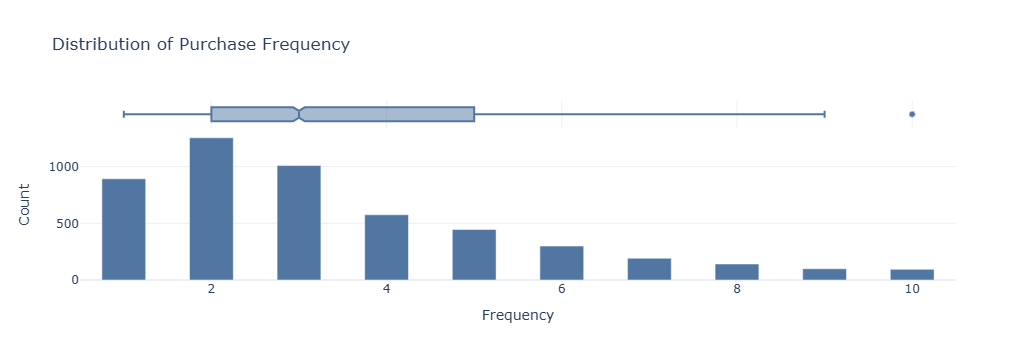

In [18]:
fig = px.histogram(
    df_customers,
    x='frequency',
    nbins=20,
    title='Distribution of Purchase Frequency',
    marginal='box',
    template='plotly_white',
    color_discrete_sequence=['#5176A1']
)

fig.update_traces(
    marker_line_color='white',
    marker_line_width=0.5
)

fig.update_layout(
    xaxis_title='Frequency',
    yaxis_title='Count'
)

fig.show()


**Висновки:**

Розподіл має чітко виражений правий хвіст, що вказує на наявність вузького сегмента надлояльних користувачів сервісу, які здійснюють до 10 покупок, що є викидом. Необхідно утримувати та повертати клієнта, таким чином стимулювати перехід клієнтів з категорії, які роблять 2-3 покупки до більш активних покупців.

**Гістограма розподілу Monetary**

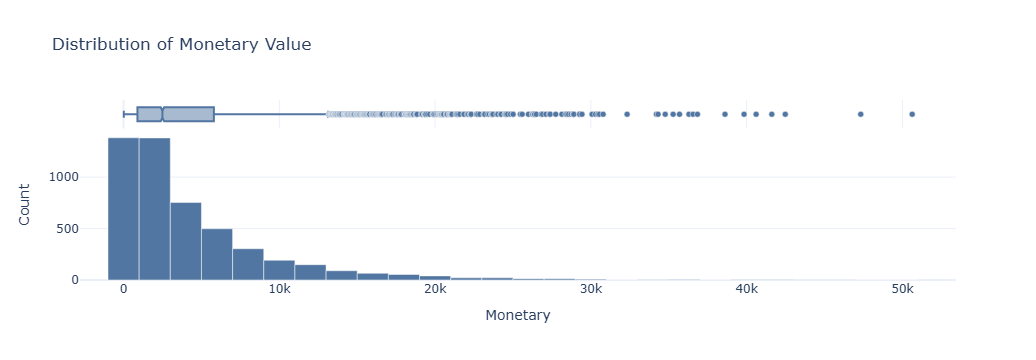

In [19]:
fig = px.histogram(
    df_customers,
    x='monetary',
    nbins=50,
    title='Distribution of Monetary Value',
    marginal='box',
    template='plotly_white',
    color_discrete_sequence=['#5176A1']
)

fig.update_traces(
    marker_line_color='white',
    marker_line_width=0.5
)

fig.update_layout(
    xaxis_title='Monetary',
    yaxis_title='Count'
)

fig.show()


**Висновки:**

Більшість клієнтів витрачають відносно невеликі суми, але також спостерігається довгий хвіст із невеликою групою клієнтів із дуже високими витратами, що створює значні викиди. Це свідчить про концентрацію виручки в сегменті High-value клієнтів і підтверджує наявність ефекту Парето, де 20% клієнтів генерують 80% доходу компанії.

**Гістограма розподілу Lifetime**

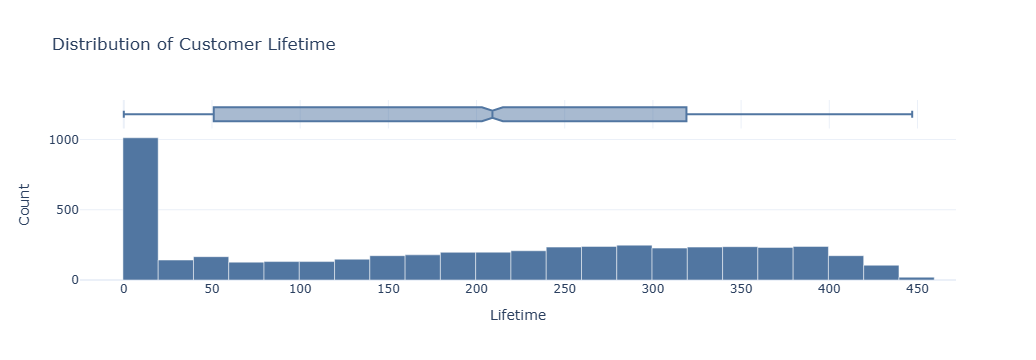

In [20]:
fig = px.histogram(
    df_customers,
    x='lifetime_days',
    nbins=40,
    title='Distribution of Customer Lifetime',
    marginal='box',
    template='plotly_white',
    color_discrete_sequence=['#5176A1']
)

fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(xaxis_title='Lifetime', yaxis_title='Count')
fig.show()


**Висновки:**

Розподіл має критичний пік у зоні 0-20 днів, що свідчить про величезну кількість клієнтів, які припиняють взаємодію майже одразу після першого замовлення. Така структура графіку підтверджує, що бізнес має проблему з першим утриманням, але ті клієнти, що залишаються понад місяць, демонструють високу стабільність і стають довготривалим активом.

## Сегментація за терміном життя клієнта

Наступним кроком я хочу виконати **сегментацію за терміном життя клієнта** та відповісти на питання: як тривалість взаємодії клієнта з компанією впливає на його поведінку, цінність та ймовірність відтоку?

In [21]:
# Сегментація клієнтів за показником lifetime 
df_customers['lifetime_segment'] = pd.cut(
    df_customers['lifetime_days'],
    bins=[-1, 100, 300, df_customers['lifetime_days'].max()],
    labels=['Short-term', 'Mid-term', 'Long-term']
)


**5. Як змінюється частота покупок серед клієнтів із різною тривалістю взаємодії з сервісом?**

Для візуалізації використаю графік Box Plot, що допоможе також оцінити викиди.

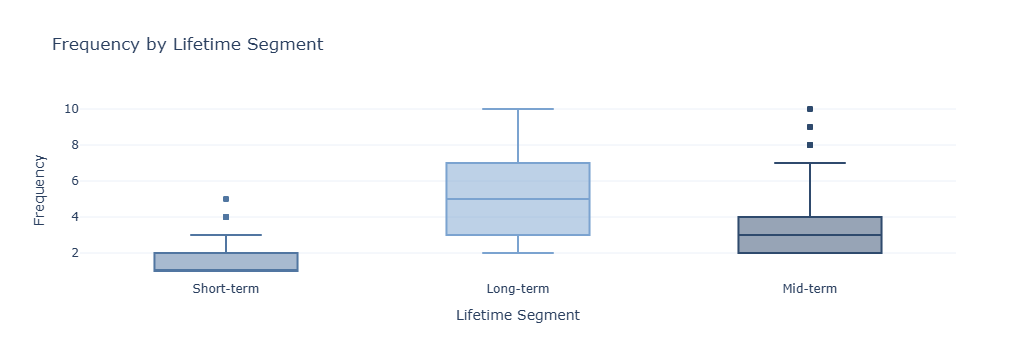

In [22]:
fig = px.box(
    df_customers,
    x='lifetime_segment',
    y='frequency',
    title='Frequency by Lifetime Segment',
    template='plotly_white',
    color='lifetime_segment',
    color_discrete_sequence=['#5176A1', '#7BA3D0', '#2F4A6D']
)

fig.update_layout(
    xaxis_title='Lifetime Segment', 
    yaxis_title='Frequency',
    showlegend=False
)

fig.show()


**Висновки:**

1. Long-term - найбільш активна група. Медіанна частота покупок - 5, а окремі клієнти роблять до 10 замовлень. Широке тіло ящика свідчить про те, що навіть усередині лояльної групи є велика різниця в активності, але загалом цей сегмент стабільно генерує повторні продажі.

2. Mid-term: медіана падає до 3 покупок і більшість клієнтів цього сегмента роблять від 2 до 4 замовлень. Наявність викидів свідчить про те, що серед них є клієнти, які за відносно короткий час вже встигли зробити 8-10 покупок.

3. Short-term: в них найнижча активність, бо медіана - 1-2 покупки, але це зрозуміло, бо вони відносно нещодавно приєднались. Ящик дуже вузький - поведінка новачків стандартна, вони рідко роблять більше 3 замовлень одразу.

**6. Чи витрачають більше ті клієнти, які залишаються з компанією довше?**

Для відповіді на це питання необхідно побудувати графік розсіювання з нанесенням лінії тренду та розфарбовуванням відповідно до lifetime сегменту.

In [23]:
fig = px.scatter(
    df_customers,
    x='lifetime_days',
    y='monetary',
    color='lifetime_segment',
    trendline='ols',
    title='Monetary Value by Customer Lifetime',
    template='plotly_white',
    color_discrete_sequence=['#5176A1', '#7BA3D0', '#2F4A6D']
)

fig.update_traces(
    marker=dict(size=6, opacity=0.6),
    marker_line_color='white',
    marker_line_width=0.5
)

fig.update_layout(
    xaxis_title='Lifetime',
    yaxis_title='Monetary',
    legend_title='Lifetime Segment'
)

fig.show()


**Висновки:**

1. Лінійна залежність: існує позитивна кореляція для всіх трьох сегментів, тобто чим довше клієнт із компанією, тим вища його сумарна цінність. Що логічно, monetary - це історичне LTV, тобто скільки за весь час клієнт вже приніс компанії.

2. Short-term: тут найвища концентрація точок біля нуля, але лінія тренду має досить крутий нахил. Саме тут є викид (крапка на рівні 50 000 при житті менше 50 днів), який сильно тягне тренд вгору на самому початку.

3. Mid-term: більшість клієнтів знаходяться в діапазоні до 10 000, лінія тренду тут виглядає найбільш стабільною та прогнозованою.

4. Long-term: лінія тренду продовжує рости, що підтверджує: клієнти, які залишилися після 300 днів, продовжують стабільно витрачати кошти. Крапки стають більш розсіяними і знаходяться вище на графіку, що підтверджує, що з плином часу monetary, як історичне LTV, тільки збільшується.


**7. Як рівень відтоку залежить від тривалості взаємодії клієнта з компанією?**

Для цього побудую стовпчиковий графік.

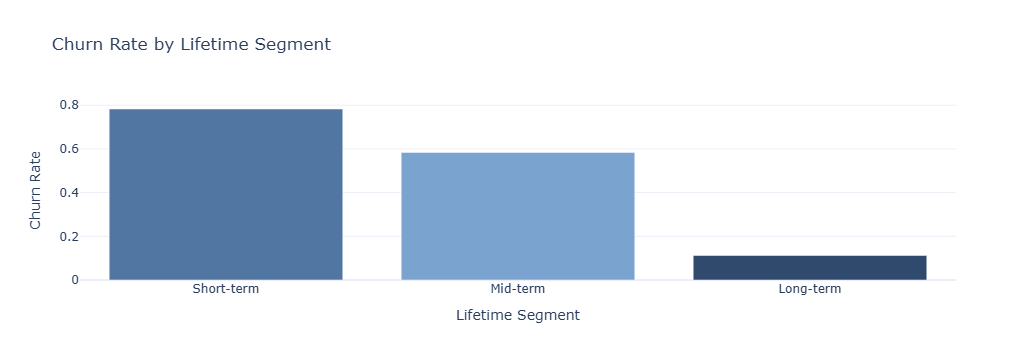

In [24]:
churn_rate = df_customers.groupby('lifetime_segment', observed=True)['churn'].mean().reset_index()

fig = px.bar(
    churn_rate,
    x='lifetime_segment',
    y='churn',
    title='Churn Rate by Lifetime Segment',
    template='plotly_white',
    color='lifetime_segment',
    color_discrete_sequence=['#5176A1', '#7BA3D0', '#2F4A6D']
)

fig.update_layout(
    xaxis_title='Lifetime Segment', 
    yaxis_title='Churn Rate',
    showlegend=False
)

fig.show()


**Висновки:**

1. Критичний рівень відтоку серед сегмента Short-term: тут зафіксовано найвищий показник відтоку - майже 0.8 (80%), це означає, що 8 з 10 нових клієнтів не повертаються після перших спроб взаємодії. Скоріше за все існують серйозні проблеми на етапі онбордингу або першого клієнтського досвіду.

2. Для Mid-term сегмента рівень відтоку падає до приблизно 0.6 (60%) і хоча ситуація краща, ніж у новачків, показник все одно залишається високим. Це те місце, де клієнт вирішує, чи стане він постійним.

3. У лояльному сегменті рівень відтоку мінімальний - близько 0.1 (10%), це підтверджує те, що якщо клієнт подолав поріг Mid-term, він з великою ймовірністю залишається з сервісом надовго.

Проведена сегментація за тривалістю взаємодії клієнта з компанією показала, що lifetime суттєво впливає на поведінку користувачів: клієнти, що довго користуються сервісом, мають вищу частоту покупок, більшу грошову цінність та нижчу ймовірність відтоку.

Однак тривалість взаємодії - це лише один із аспектів клієнтської поведінки. Щоб глибше зрозуміти як формується цінність клієнта, я хочу дослідити, які саме фактори визначають високий monetary.
Тому наступним кроком є аналіз взаємозв’язку між frequency та monetary.


**8. Чи справді клієнти, які купують частіше, витрачають більше?**

Якісно покаже цю взаємодію точковий графік з трендовою лінією та розфарбовуванням відповідно до lifetime сегменту.

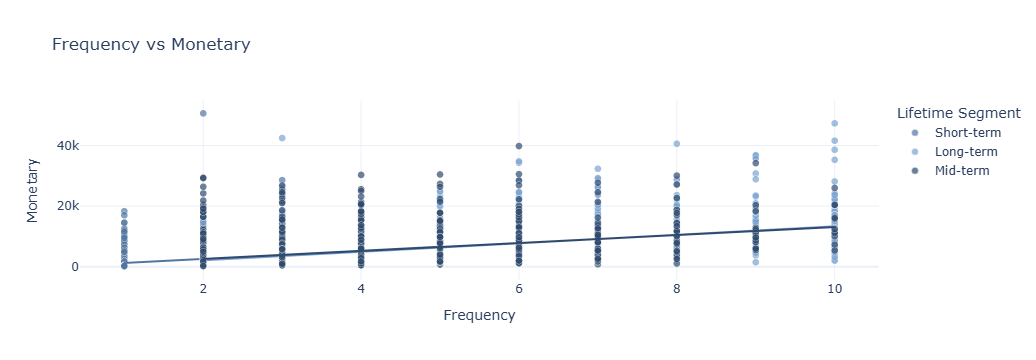

In [25]:
fig = px.scatter(
    df_customers,
    x='frequency',
    y='monetary',
    color='lifetime_segment',
    title='Frequency vs Monetary',
    template='plotly_white',
    color_discrete_sequence=['#5176A1', '#7BA3D0', '#2F4A6D'],
    trendline='ols'
)

fig.update_traces(
    marker=dict(size=7, opacity=0.7),
    marker_line_color='white',
    marker_line_width=0.5
)

fig.update_layout(
    xaxis_title='Frequency',
    yaxis_title='Monetary',
    legend_title='Lifetime Segment'
)

fig.show()


**Висновки:**


1. Лінія тренду підіймається вгору, підтверджуючи: кожна наступна покупка стабільно збільшує monetary. 

2. Сегментний розподіл:

- Short-term: точки зосереджені переважно зліва (низька частота покупок), але мають аномальні викиди вгору.

- Long-term: точки рівномірно розподілені вздовж усієї лінії тренду, що робить їх найнадійнішим джерелом доходу.

3. Компанія отримує гроші двома шляхами: через рідкісні, але надвеликі чеки від новачків (frequency - 2, 3 покупки) та через масові прогнозовані платежі від лояльних клієнтів (frequency - 8, 9, 10 покупок).

## Перевірка статистичної гіпотези

Хочу поглибити аналіз і статистично перевірити, чи справді клієнти з високою цінністю (High‑value), тобто топ‑20% за показником monetary, мають вищу частоту покупок, ніж решта клієнтів.

**Формулювання гіпотез:**

 - Нульова гіпотеза $H_о$ :  середня частота покупок у High‑value клієнтів не відрізняється від середньої частоти покупок інших клієнтів.
 - Альтернативна гіпотеза $H_a$ :  High‑value клієнти мають вищу частоту покупок, ніж інші.

Це правосторонній тест.

**Метод:** для перевірки гіпотези використаю t‑тест для двох незалежних вибірок.


In [26]:
# Визначення порогу (80-ий перcентиль)
threshold = df_customers['monetary'].quantile(0.8)

# Створення сегментів
df_customers['value_segment'] = np.where(
    df_customers['monetary'] >= threshold,
    'High-value',
    'Other'
)


In [27]:
# Формування вибірки для t‑test
high_value = df_customers[df_customers['value_segment'] == 'High-value']['frequency']
other = df_customers[df_customers['value_segment'] == 'Other']['frequency']


In [28]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_value, other, equal_var=False)

print(f"Результати t-тесту:")
print(f"t-statistic:  {t_stat:.3f}")
print(f"p-value:      {p_value:.5f}")


Результати t-тесту:
t-statistic:  30.735
p-value:      0.00000


**Інтерпретація:**

Так як p‑value < 0.05, нульова гіпотеза **відхиляється**, і можна зробити висновок, що High‑value клієнти статистично значуще частіше здійснюють покупки, ніж інші користувачі. Це підтверджує думку, що висока цінність клієнта пов’язана з більшою інтенсивністю покупок.


Тепер побудую **графік розподілу частоти покупок за сегментами цінності клієнта**.

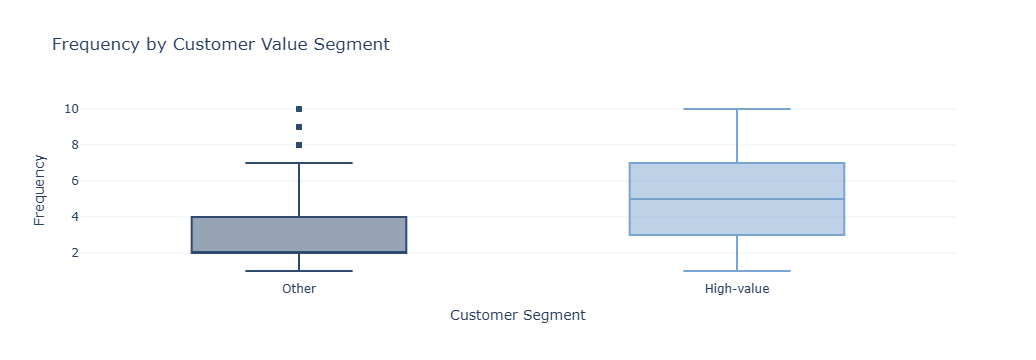

In [29]:
fig = px.box(
    df_customers,
    x='value_segment',
    y='frequency',
    color='value_segment',
    title='Frequency by Customer Value Segment',
    template='plotly_white',
    color_discrete_sequence=['#2F4A6D', '#7BA3D0']
)

fig.update_layout(
    xaxis_title='Customer Segment',
    yaxis_title='Frequency',
    showlegend=False
)

fig.show()


**Висновки:**

1. Медіана покупок для High-value клієнтів становить 5, тоді як для решти клієнтів - лише 3.

2. Boxplot показує, що 75% клієнтів High-value мають частоту покупок від 3 до 7, що свідчить про їхню високу активність та стабільну лояльність до бренду.

**Рекомендації:** 

Стратегія утримання має бути сфокусована на збільшенні частоти покупок клієнтом. Якщо простимулювати клієнта з групи Other зробити 4-ту чи 5-ту покупку, ймовірність того, що він перейде в топ-сегмент за прибутком значно зростає.

**9. Як давність останньої покупки впливає на ймовірність відтоку клієнта?**

Так як для даного аналізу було використано бізнес-правило, за яким клієнт вважається таким, що пішов (сhurn=1), якщо період його неактивності - recency перевищує 90 днів, то хочу продемонструвати цей поріг на візуалізації.

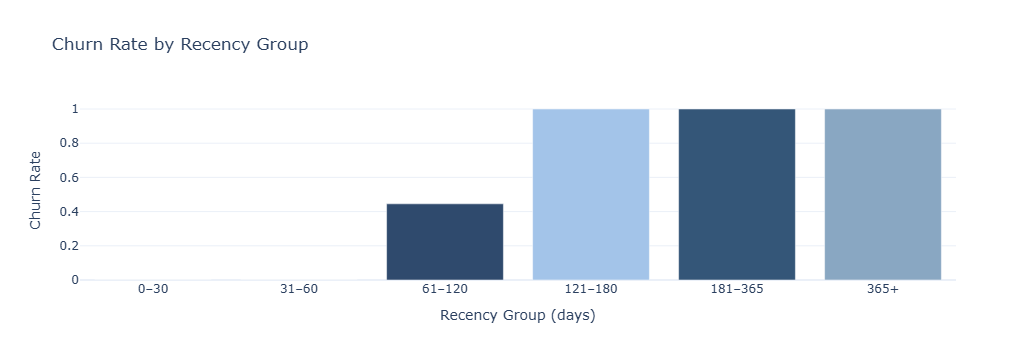

In [30]:
df_customers['recency_bin'] = pd.cut(
    df_customers['recency_days'],
    bins=[-1, 30, 60, 120, 180, 365, df_customers['recency_days'].max()],
    labels=['0–30', '31–60', '61–120', '121–180', '181–365', '365+']
)

recency_churn = df_customers.groupby('recency_bin', observed=True)['churn'].mean().reset_index()

fig = px.bar(
    recency_churn,
    x='recency_bin',
    y='churn',
    title='Churn Rate by Recency Group',
    template='plotly_white',
    color='recency_bin',
    color_discrete_sequence=['#5176A1', '#7BA3D0', '#2F4A6D', '#A3C4E9', '#345678', '#89A7C2']
)

fig.update_layout(
    xaxis_title="Recency Group (days)",
    yaxis_title="Churn Rate",
    showlegend=False
)

fig.show()


**Висновки:**

1. Підтвердження сегментації: нульовий відтік у групах до 60 днів та різкий стрибок до 100% відтоку після позначки 121 день. Це підтверджує, що дані коректно розподілені згідно з обраною бізнес-логікою.

2. Вибір 90-денного вікна має стратегічне значення: саме в інтервалі 61-120 днів, де сhurn становить 45%, треба влаштовувати маркетингові кампанії з повернення, бо клієнт ще не перейшов межу гарантованого відтоку.


## Основні інсайти блоку аналізу на рівні клієнта:

**1. Поведінка та активність клієнтів**

- Середнє значення frequency - 3-4 покупки, але 25% клієнтів роблять лише 1-2 замовлення, що вказує на слабку ранню залученість.

- Lifetime у середньому становить 196 днів, а частина клієнтів залишається понад рік, це свідчить про наявність стабільного ядра лояльних користувачів.

**2. Цінність клієнтів (monetary/LTV)**

- Середній monetary - 4355, але медіана - 2493, що показує сильну нерівномірність розподілу доходу, бо невелика група клієнтів генерує великі суми.

- Максимальний чек у 50 628 підтверджує наявність високовартісних аномальних покупок, які суттєво впливають на загальний дохід.

**3. Динаміка розвитку клієнта**

- Short‑term - низька активність (1-2 покупки), але інколи трапляються великі чеки. Це нестабільний сегмент із високим ризиком відтоку.

- Mid‑term - активність зростає до 2-4 покупок, з’являються перші ознаки лояльності. Саме тут клієнт вирішує, чи залишиться надовго.

- Long‑term - найстабільніший сегмент - медіана частоти 5 покупок, окремі клієнти роблять до 10. Розкид великий, але загальна тенденція на стійке зростання LTV з часом.

**4. Утримання та відтік**

- Загальний рівень churn - 51%, але він різко відрізняється між сегментами.

- Short‑term churn - 80% - критична зона: більшість нових клієнтів не повертаються після перших взаємодій.

- Mid‑term churn - 60% - точка прийняття рішення, де клієнт або переходить у лояльність, або йде.

- Long‑term churn - 10% - якщо клієнт залишився після 300 днів, він майже гарантовано стає стабільним джерелом доходу.

## Рекомендації (Retention Strategy)

На основі аналізу відтоку, можна виділити три критичні фази, коли маркетингові комунікації мають найвищий вплив:

**1.** Онбординг (1-30 днів) - найвищий стовпчик відтоку був саме в перші 20-30 днів (гістограма розподілу Distribution of Customer Lifetime), це клієнти, які зробили одне замовлення і зникли.

*Дія:* На 14-й день після першої покупки відправити «Welcome-бонус» або опитування «Як вам наше замовлення?». Мета - сформувати звичку.
 
**2.** Ризик (31-60 днів) - тут рівень відтоку ще низький, але клієнт починає забувати про бренд.

*Дія:* На 45-й день надіслати персоналізовану добірку товарів на основі категорій, які клієнт уже купував. Слід використовувати модель ML, щоб підібрати саме те, що йому цікаво.

**3.** Критичне вікно (61-90 днів) - це те місце, де сhurnзбільшується до 45%, а після 90 днів клієнт майже гарантовано відтікає.

*Дія:* На 75-й день запропонувати велику знижку або безкоштовну доставку, щоб повернути клієнта, поки він не перетнув позначку в 90 днів неактивності.

Виходячи з рекомендацій для другої фази (ризик), необхідно персоналізувати пропозиції товарів. Найкраще це робити за допомогою **Item‑based Collaborative Filtering** - моделі рекомендацій, яка визначає схожість між товарами та дозволяє пропонувати клієнту саме ті позиції, які найбільш відповідають його попереднім покупкам. Для цього буду використовувати **таблицю замовлень df_orders**.

## Item‑based Collaborative Filtering

**Створення матриці "клієнт х категорія"**

In [31]:
customer_category = df_orders.groupby(['Customer_ID', 'Product_Category'])['Order_ID'].count().unstack().fillna(0)
customer_category.head(5)

Product_Category,Beauty,Books,Electronics,Fashion,Food,Home & Garden,Sports,Toys
Customer_ID,,,,,,,,
CUST_00001,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
CUST_00002,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CUST_00003,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
CUST_00004,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CUST_00005,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


**Обчислення схожості між категоріями**

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(customer_category.T)
similarity_df = pd.DataFrame(similarity, index=customer_category.columns, columns=customer_category.columns)


**Функція рекомендацій**

In [33]:
def recommend_categories(Customer_ID, top_n=3):
    customer_vector = customer_category.loc[Customer_ID]
    purchased = customer_vector[customer_vector > 0].index
    
    scores = similarity_df[purchased].mean(axis=1)
    scores = scores.drop(purchased)  # не рекомендується те, що вже купляв
    
    return scores.sort_values(ascending=False).head(top_n)


**Прогнозування рекомендованих категорій**

In [34]:
first_5_customers = customer_category.index[:5]

for cid in first_5_customers:
    print(f"Рекомендації для клієнта {cid}:")
    print(recommend_categories(cid))
    print("-" * 40)


Рекомендації для клієнта CUST_00001:
Product_Category
Electronics    0.331590
Food           0.329201
Toys           0.324178
dtype: float64
----------------------------------------
Рекомендації для клієнта CUST_00002:
Product_Category
Sports         0.337213
Electronics    0.329343
Toys           0.323627
dtype: float64
----------------------------------------
Рекомендації для клієнта CUST_00003:
Product_Category
Electronics    0.326602
Food           0.324691
Books          0.320587
dtype: float64
----------------------------------------
Рекомендації для клієнта CUST_00004:
Product_Category
Sports         0.329575
Books          0.320478
Electronics    0.318553
dtype: float64
----------------------------------------
Рекомендації для клієнта CUST_00005:
Product_Category
Electronics    0.323919
Sports         0.323174
Food           0.321236
dtype: float64
----------------------------------------


## Побудова моделі лінійної регресії з прогнозування відтоку клієнтів

Для вирішення проблеми з відтоком, яка була виявлена раніше, я хочу створити модель логістичної регресії, яка б могла одночасно враховувати всі ключові показники з **таблиці клієнтів df_customers** (frequency, monetary, lifetime) і робити такий прогноз.

Так як показник recency було використано для створення цільової змінної сhurn, то цей показник не може бути використаний як ознака для навчання моделі, щоб уникнути витоку даних.

**Побудова кореляційної матриці**

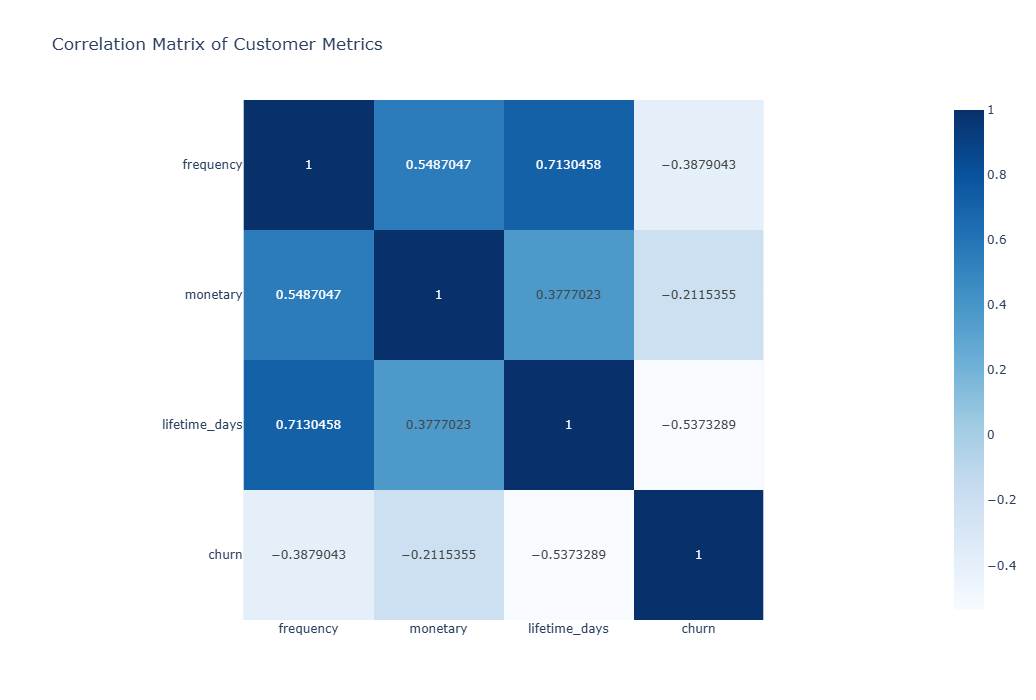

In [35]:
corr_matrix = df_customers[['frequency', 'monetary', 'lifetime_days', 'churn']].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='Blues',
    title='Correlation Matrix of Customer Metrics',
)

fig.update_layout(height=700)
fig.show()


**Висновки:**

1. Сhurn найбільш негативно корелює з lifetime: чим довше клієнт з компанією, тим менша ймовірність відтоку. Це підтверджує попередню сегментацію за lifetime.

2. Сhurn також негативно корелює з frequency: чим частіше клієнт купує, тим менша ймовірність відтоку, що логічно, бо лояльні клієнти рідше йдуть.

3. Інша залежність: monetary найсильніше залежить від frequency: чим частіше клієнт купує, тим більше він приносить доходу, що підтверджується попереднім дослідженням цих величин.


**Розділення даних на навчальну та тестову вибірки**

In [36]:
from sklearn.model_selection import train_test_split

# Вибір ознак
X = df_customers[['frequency', 'monetary', 'lifetime_days']]
y = df_customers['churn']

# Розділення на вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 3
Розмір вибірки: 5000


**Масштабування даних**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Навчання моделі логістичної регресії**

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Прогнозування на тренувальній та тестовій вибірках**

In [39]:
# Прогнозування
y_test_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Таблиця з прогнозами
sample_predictions = pd.DataFrame({
    'Реальний статус': y_test.values[:5],
    'Прогноз моделі': y_test_pred[:5],
    'Ймовірність залишитися': y_pred_proba[:5, 0].round(3),
    'Ймовірність відтоку': y_pred_proba[:5, 1].round(3)
})

print("\nПриклад прогнозів для перших 5 клієнтів (Тестова вибірка):")
sample_predictions.head(5)


Приклад прогнозів для перших 5 клієнтів (Тестова вибірка):


,Реальний статус,Прогноз моделі,Ймовірність залишитися,Ймовірність відтоку
0,0,1.0,0.349,0.651
1,1,0.0,0.711,0.289
2,0,1.0,0.388,0.612
3,1,1.0,0.455,0.545
4,1,1.0,0.243,0.757


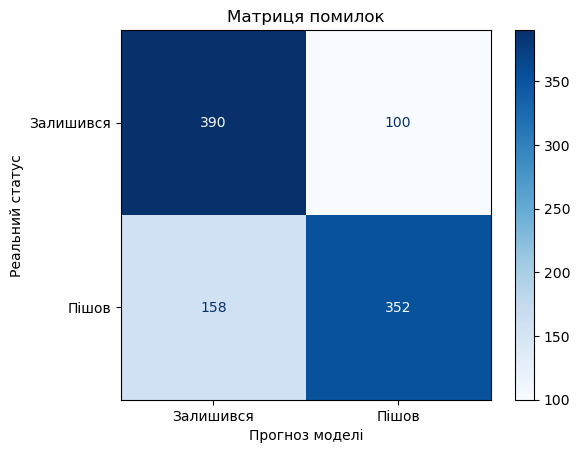

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Залишився', 'Пішов'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.xlabel('Прогноз моделі')
plt.ylabel('Реальний статус')
plt.show()

**Висновки:**

1.  Модель вірно ідентифікувала 742 клієнти (390 + 352) із 1000, тобто загальна якість моделі на рівні вище середнього.

2.  Модель пропустила 158 клієнтів, які фактично пішли, хоча вважались лояльними. Це несе за собою комерційні втрати, бо як правило дешевше утримати існуючого клієнта, ніж залучити нового, тому це - найдорожча помилка алгоритму. Для мінімізації цих втрат у майбутньому варто додати до моделі більше поведінкових ознак (наприклад, зміна кошика, скарги в підтримку або активність у мобільному додатку), щоб навчитись краще розпізнавати "тихий відтік".

3. Здатність точно виявити 352 клієнти, що реально збиралися піти, дозволяє впровадити точкову стратегію утримання для третини всієї тестової вибірки вже зараз і це добре.


**Обчислення метрик якості моделі accuracy, precision, recall, f1**

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"\nAccuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:

Accuracy (Точність):    0.742
Precision (Влучність):  0.779
Recall (Повнота):       0.690
F1-score:               0.732


**Висновок:**

- Accuracy (Точність) = 0.742 - модель правильно класифікує близько 74% прикладів.
- Precision (Влучність) = 0.779 - якщо модель каже, що клієнт піде, вона права у 78% випадків.
- Recall (Повнота) = 0.69 - модель успішно ідентифікує 69% клієнтів, які реально планують піти. Це непоганий показник, проте він вказує на слабке місце: 31% відтоку залишається непоміченим.
- F1-score = 0.732 - говорить про середню якість класифікації дефолтів, це значення прийнятне для початкової моделі.


**Побудова ROC-кривої та обчислення значення AUC**

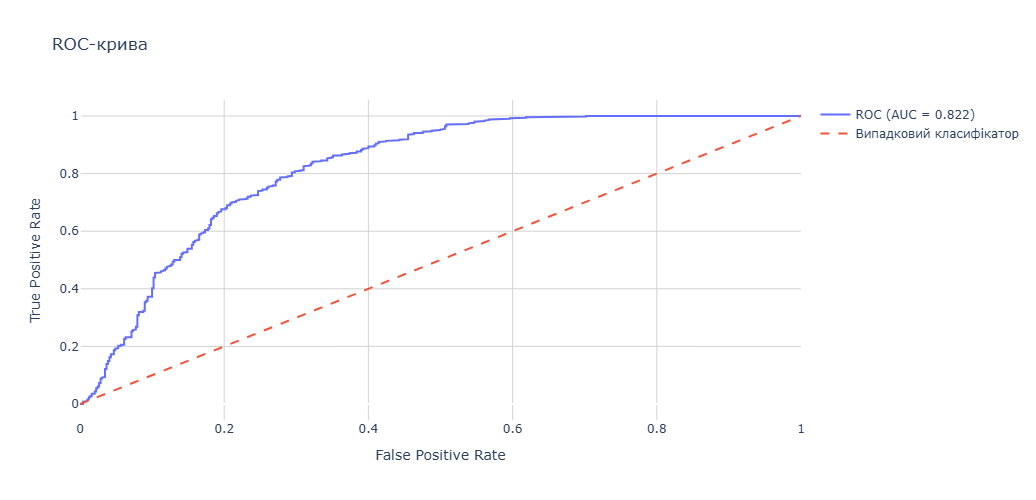

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Обчислення ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# Побудова графіка
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

Так як значення AUC = 0.822, то створена модель в цілому адекватна.

**Аналіз важливості ознак**

In [43]:
# Обчислення коефіцієнтів моделі
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance.round(3)


,feature,coefficient,abs_coefficient
2,lifetime_days,-1.276,1.276
1,monetary,-0.053,0.053
0,frequency,-0.002,0.002


**Висновки:**

За результатами логістичної регресії:

- найбільш значущий фактор - lifetime_days (-1.276) свідчить про те, що клієнти з довшим періодом взаємодії з сервісом мають суттєво нижчу ймовірність churn.

- monetary також має негативний вплив, але значно слабший (-0.053), що означає: клієнти з вищими витратами дещо рідше йдуть у відтік.

- frequency практично не впливає на churn (-0.002), що може свідчити про її кореляцію з іншими змінними або про те, що частота покупок сама по собі не є ключовим фактором утримання.


**Оптимізація порогу та його аналіз для покращення моделі**

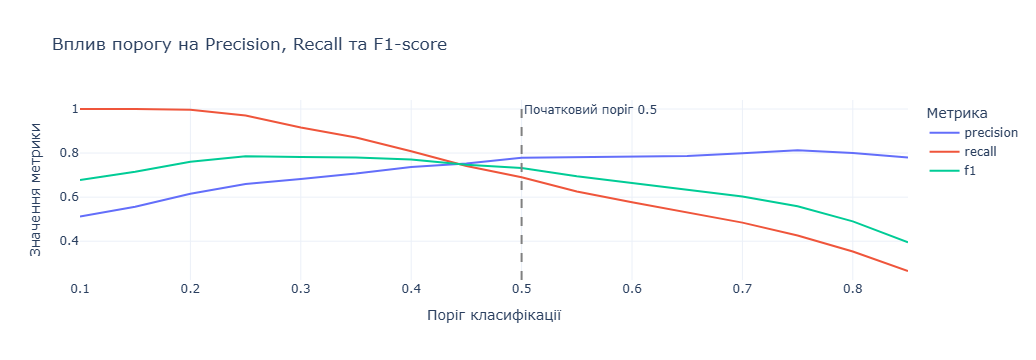

In [45]:
# Аналіз різних порогів (від 0.1 до 0.9 з кроком 0.05)
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)
    
    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom, zero_division=0),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

threshold_results_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація через Plotly
fig = px.line(
    threshold_results_df.melt(id_vars='threshold'), 
    x='threshold', 
    y='value', 
    color='variable',
    title='Вплив порогу на Precision, Recall та F1-score',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг класифікації', 'variable': 'Метрика'},
    template='plotly_white'
)

# Лінія стандартного порогу 0.5 для орієнтиру
fig.add_vline(x=0.5, line_dash="dash", line_color="gray", annotation_text="Початковий поріг 0.5")

fig.show()

Оптимальний поріг класифікацї, зображений на графіку - 0.45.

**Побудова матриці помилок для нового оптимального порогу 0.45**

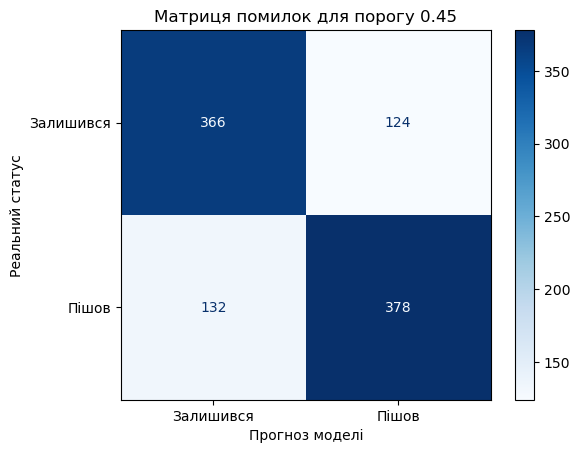

In [48]:
y_pred_opt = y_pred_proba[:,1]>=0.45

cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Залишився', 'Пішов'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок для порогу 0.45')
plt.xlabel('Прогноз моделі')
plt.ylabel('Реальний статус')
plt.show()

**Висновки:**

Якщо порівняти початкову матрицю (поріг 0.5) та нову матрицю (поріг 0.45), то кількість клієнтів, які фактично пішли, хоча вважались лояльними зменшилась з 158 до 132 - а це критична зона, покращення якої зменшує фінансові ризики.

**Обчислення метрик якості моделі accuracy, precision, recall, f1 для покращеної моделі**

In [47]:
accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)

print("МЕТРИКИ ЯКОСТІ ПОКРАЩЕНОЇ МОДЕЛІ:")
print(f"\nAccuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ ПОКРАЩЕНОЇ МОДЕЛІ:

Accuracy (Точність):    0.744
Precision (Влучність):  0.753
Recall (Повнота):       0.741
F1-score:               0.747


**Висновки:**

Всі показники метрик моделі з порогом 0.45 покращились, модель стала більш точною, тому використання нового порогу є обґрунтованим і стратегічно правильним.

## Загальний висновок:

Проведений аналіз дозволив комплексно оцінити поведінку клієнтів e‑commerce платформи та визначити ключові фактори, що впливають на їхню активність і відтік. На основі дослідження було сформовано **retention‑стратегію**, яка враховує життєвий цикл клієнта та дозволяє вчасно реагувати на ризик зниження залученості.

Побудована **Item‑based Collaborative Filtering** рекомендаційна система підсилює цю стратегію, забезпечуючи персоналізовані пропозиції на основі історії покупок та схожості товарних категорій. Це створює можливість не лише утримувати клієнтів, а й збільшувати їхню цінність через релевантні рекомендації.

**Модель логістичної регресії для прогнозування churn** дала змогу кількісно оцінити ймовірність відтоку кожного клієнта та визначити найбільш впливові фактори. Це дозволяє бізнесу спрямовувати ресурси на сегменти з найвищим ризиком.

У сукупності ці три компоненти формують цілісну аналітичну систему, яка допомагає:
 - краще розуміти поведінку клієнтів,
 - підвищувати ефективність маркетингових активностей,
 - зменшувати відтік,
 - збільшувати довгострокову цінність клієнтів.
